In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings
from features import get_summarized_season
from clustering import group_pca, add_team_clusters
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import log_loss
from sklearn.calibration import CalibratedClassifierCV
from itertools import combinations

warnings.filterwarnings("ignore")

data_dir = "/Users/loganheydt/Desktop/Data/GitHub/Kaggle_competitions/March_Machine_Learning_Mania_2026/data"


In [135]:
M_regular_results = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")

In [136]:
cut_off = 2005

regular_results = M_regular_results.loc[M_regular_results['Season'] >= cut_off]
tourney_results = M_tourney_results.loc[M_tourney_results['Season'] >= cut_off]
seeds = M_seeds.loc[M_seeds['Season'] >= cut_off]

# regular_results = W_regular_results.loc[W_regular_results['Season'] >= cut_off]
# tourney_results = W_tourney_results.loc[W_tourney_results['Season'] >= cut_off]
# seeds = W_seeds.loc[W_seeds['Season'] >= cut_off]


In [137]:
regular_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,...,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,...,16,17,27,21,15,12,10,7,1,14


In [138]:
tourney_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,...,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,...,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,...,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,...,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,...,21,15,20,10,26,16,14,5,8,19


In [139]:
max_day = tourney_results['DayNum'].max()

In [140]:
seeds.head()

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374


In [141]:
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))
seeds["division"] = seeds["Seed"].apply(lambda x: x[0])

seeds.head()

,Season,Seed,TeamID,seed,division
0,1985,W01,1207,1,W
1,1985,W02,1210,2,W
2,1985,W03,1228,3,W
3,1985,W04,1260,4,W
4,1985,W05,1374,5,W


In [142]:
champs = tourney_results.loc[tourney_results['DayNum']==max_day]
champs = champs.rename(columns={'WTeamID': 'TeamID'})
champs = champs.merge(seeds, how='left', on=['Season', 'TeamID'])

In [143]:
champs['seed'].value_counts().sort_index()

seed
1    15
2     2
3     3
4     1
7     1
Name: count, dtype: int64

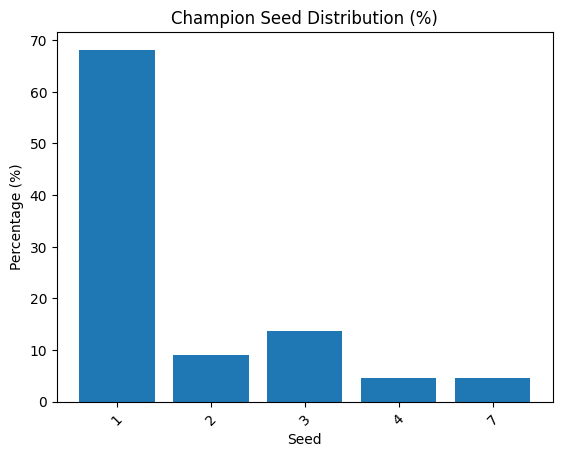

In [144]:
seed_pct = (
    champs['seed']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure()
plt.bar(seed_pct.index.astype(str), seed_pct.values)

plt.xlabel("Seed")
plt.ylabel("Percentage (%)")
plt.title("Champion Seed Distribution (%)")
plt.xticks(rotation=45)

plt.show()

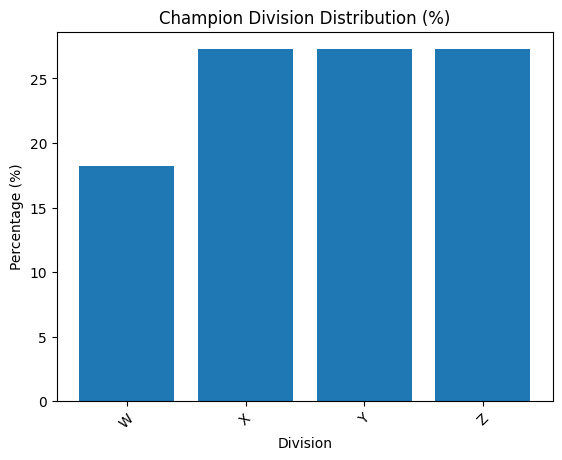

In [145]:
div_pct = (
    champs['division']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure()
plt.bar(div_pct.index.astype(str), div_pct.values)

plt.xlabel("Division")
plt.ylabel("Percentage (%)")
plt.title("Champion Division Distribution (%)")
plt.xticks(rotation=45)

plt.show()

In [146]:
tourney_results = tourney_results.merge(
    seeds[['Season', 'TeamID', 'seed']],
    left_on=['Season', 'WTeamID'],
    right_on=['Season', 'TeamID'],
    how='left'
).rename(columns={'seed': 'Wseed'})

tourney_results = tourney_results.merge(
    seeds[['Season', 'TeamID', 'seed']],
    left_on=['Season', 'LTeamID'],
    right_on=['Season', 'TeamID'],
    how='left'
).rename(columns={'seed': 'Lseed'})

In [147]:
tourney_results['seed_dif'] = tourney_results['Wseed'] - tourney_results['Lseed']
tourney_results['point_dif'] = tourney_results['WScore'] - tourney_results['LScore']

In [148]:
tourney_results[['seed_dif', 'point_dif']].corr()

,seed_dif,point_dif
seed_dif,1.000000,-0.394906
point_dif,-0.394906,1.000000


In [149]:
mens_season_stats = get_summarized_season(df=M_regular_results, seeds=M_seeds)

In [150]:
mens_season_stats.columns

Index(['games', 'is_win', 'possessions_avg', 'Score', 'FGM', 'FGA', 'FGM3',
       'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF',
       'opp_Score', 'opp_FGM', 'opp_FGA', 'opp_FGM3', 'opp_FGA3', 'opp_FTM',
       'opp_FTA', 'opp_OR', 'opp_DR', 'opp_Ast', 'opp_TO', 'opp_Stl',
       'opp_Blk', 'opp_PF', 'win_pct', 'points_per_game', 'blk_per_game',
       'ast_per_game', 'stl_per_game', 'pf_per_game', 'opp_points_per_game',
       'opp_blk_per_game', 'opp_ast_per_game', 'opp_stl_per_game',
       'opp_pf_per_game', 'fg_pct', 'fg3_pct', 'ft_pct', 'opp_fg_pct',
       'opp_fg3_pct', 'opp_ft_pct', 'off_rating', 'def_rating', 'net_rating',
       'efg', 'opp_efg', 'tov_rate', 'opp_tov_rate', 'ft_rate', 'opp_ft_rate',
       'orb_margin_pg', 'drb_margin_pg', 'pos_per_game', 'seed'],
      dtype='object')

## PCA

In [151]:
reduced_df, fitted_pca_objects = group_pca(
    df=mens_season_stats
)

In [152]:
# Elbow method
inertias = []
mapping1 = {}
K = range(1,10)

for k in K:
    model = KMeans(k, random_state=7).fit(reduced_df.values)
    labels = model.labels_
    centers = model.cluster_centers_

    inertias.append(model.inertia_)

    mapping1[k] = inertias[-1]

Inertia values:
1 : 274959.583978023
2 : 209737.903833949
3 : 184259.0782013643
4 : 167968.91333337774
5 : 158455.50305216014
6 : 149876.55972539954
7 : 143877.4596523941
8 : 139513.32823738497
9 : 135749.8689806643


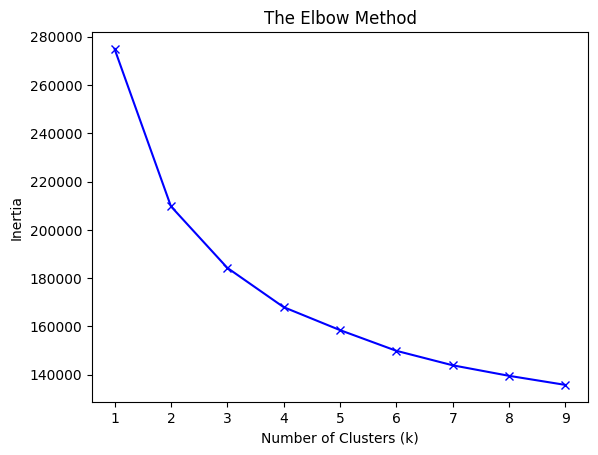

In [153]:
print("Inertia values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method')
plt.show()

In [154]:
out, _, _ = add_team_clusters(mens_season_stats)

In [155]:
out.columns

Index(['games', 'is_win', 'possessions_avg', 'Score', 'FGM', 'FGA', 'FGM3',
       'FGA3', 'FTM', 'FTA', 'OR', 'DR', 'Ast', 'TO', 'Stl', 'Blk', 'PF',
       'opp_Score', 'opp_FGM', 'opp_FGA', 'opp_FGM3', 'opp_FGA3', 'opp_FTM',
       'opp_FTA', 'opp_OR', 'opp_DR', 'opp_Ast', 'opp_TO', 'opp_Stl',
       'opp_Blk', 'opp_PF', 'win_pct', 'points_per_game', 'blk_per_game',
       'ast_per_game', 'stl_per_game', 'pf_per_game', 'opp_points_per_game',
       'opp_blk_per_game', 'opp_ast_per_game', 'opp_stl_per_game',
       'opp_pf_per_game', 'fg_pct', 'fg3_pct', 'ft_pct', 'opp_fg_pct',
       'opp_fg3_pct', 'opp_ft_pct', 'off_rating', 'def_rating', 'net_rating',
       'efg', 'opp_efg', 'tov_rate', 'opp_tov_rate', 'ft_rate', 'opp_ft_rate',
       'orb_margin_pg', 'drb_margin_pg', 'pos_per_game', 'seed',
       'team_cluster'],
      dtype='object')

In [156]:
cluster_summary = out.groupby(['team_cluster']).mean()
cluster_summary

,games,is_win,possessions_avg,Score,FGM,FGA,FGM3,FGA3,FTM,FTA,...,efg,opp_efg,tov_rate,opp_tov_rate,ft_rate,opp_ft_rate,orb_margin_pg,drb_margin_pg,pos_per_game,seed
team_cluster,,,,,,,,,,,,,,,,,,,,,
0,30.655649,20.830529,2084.579244,2200.519832,777.287861,1727.036659,203.788462,583.599159,442.155649,632.804087,...,0.509415,0.467915,0.191548,0.202722,0.367233,0.341084,0.512042,0.522816,68.038541,8.218750
1,28.809304,12.251958,2005.988772,2064.030861,723.824505,1647.255182,212.874712,612.944265,403.507140,564.836942,...,0.504429,0.520619,0.181916,0.178284,0.343852,0.349709,0.484763,0.488750,69.680888,14.288462
2,29.352296,13.730689,1981.013576,1943.977557,683.800626,1619.390919,177.378392,541.049061,398.997912,585.128914,...,0.477340,0.488543,0.206227,0.205714,0.361818,0.378119,0.508399,0.496081,67.549722,13.731183
3,30.132455,20.474051,2092.061938,2315.226956,815.445391,1737.090627,240.481022,651.859024,443.855151,607.460883,...,0.539029,0.492270,0.170255,0.175628,0.350919,0.314606,0.498716,0.525206,69.486187,8.070018
4,28.262270,6.728528,1934.908522,1801.840491,634.282975,1566.796779,171.235429,537.855828,362.039110,535.266104,...,0.459701,0.523156,0.209995,0.194200,0.342169,0.391346,0.485285,0.466494,68.518551,16.000000


In [157]:
M_tourney_results.columns

Index(['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',
       'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR',
       'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3',
       'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF'],
      dtype='object')

In [158]:
cluster_strength = (
    out.groupby("team_cluster")["win_pct"]
    .mean()
    .to_dict()
)

In [159]:
def expected_win_prob(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))


def margin_multiplier(score_a, score_b, elo_a, elo_b):
    """
    Optional margin-of-victory adjustment.
    Keeps blowouts from being treated the same as 1-point wins.
    """
    margin = abs(score_a - score_b)
    elo_diff = abs(elo_a - elo_b)

    return np.log(margin + 1) * (2.2 / ((elo_diff * 0.001) + 2.2))


def build_elo_ratings(
    game_df,
    k=20,
    base_elo=1500,
    use_margin=True,
    carry_over=0.75
):
    """
    Build Elo ratings from game-level results.

    Parameters
    ----------
    game_df : pd.DataFrame
        Must contain Season, DayNum, WTeamID, LTeamID, WScore, LScore
    k : float
        Elo update sensitivity
    base_elo : float
        Starting Elo for new teams / reset point
    use_margin : bool
        Whether to use margin-of-victory multiplier
    carry_over : float
        Fraction of prior season Elo retained into next season.
        Example: 0.75 means 75% prior Elo, 25% reset to base_elo.

    Returns
    -------
    elo_game_log : pd.DataFrame
        One row per game with pre/post Elo values
    season_ending_elo : pd.DataFrame
        Final Elo by Season, TeamID
    """

    df = game_df.copy()
    df = df.sort_values(["Season", "DayNum"]).reset_index(drop=True)

    current_elo = {}
    last_season_seen = None
    game_rows = []

    for _, row in df.iterrows():
        season = row["Season"]
        wteam = row["WTeamID"]
        lteam = row["LTeamID"]
        wscore = row["WScore"]
        lscore = row["LScore"]

        # Handle season transition
        if last_season_seen is None:
            last_season_seen = season
        elif season != last_season_seen:
            # carry prior season ratings partially into new season
            for team_id in list(current_elo.keys()):
                current_elo[team_id] = (
                    carry_over * current_elo[team_id]
                    + (1 - carry_over) * base_elo
                )
            last_season_seen = season

        # initialize teams if unseen
        if wteam not in current_elo:
            current_elo[wteam] = base_elo
        if lteam not in current_elo:
            current_elo[lteam] = base_elo

        pre_w_elo = current_elo[wteam]
        pre_l_elo = current_elo[lteam]

        exp_w = expected_win_prob(pre_w_elo, pre_l_elo)
        exp_l = 1 - exp_w

        actual_w = 1
        actual_l = 0

        mult = margin_multiplier(wscore, lscore, pre_w_elo, pre_l_elo) if use_margin else 1.0

        new_w_elo = pre_w_elo + k * mult * (actual_w - exp_w)
        new_l_elo = pre_l_elo + k * mult * (actual_l - exp_l)

        current_elo[wteam] = new_w_elo
        current_elo[lteam] = new_l_elo

        game_rows.append({
            "Season": season,
            "DayNum": row["DayNum"],
            "WTeamID": wteam,
            "LTeamID": lteam,
            "WScore": wscore,
            "LScore": lscore,
            "W_pre_elo": pre_w_elo,
            "L_pre_elo": pre_l_elo,
            "W_post_elo": new_w_elo,
            "L_post_elo": new_l_elo
        })

    elo_game_log = pd.DataFrame(game_rows)

    # Build end-of-season team Elo table
    season_ending = []

    for season, season_games in elo_game_log.groupby("Season"):
        last_w = (
            season_games[["WTeamID", "W_post_elo"]]
            .rename(columns={"WTeamID": "TeamID", "W_post_elo": "elo"})
        )
        last_l = (
            season_games[["LTeamID", "L_post_elo"]]
            .rename(columns={"LTeamID": "TeamID", "L_post_elo": "elo"})
        )

        season_team_elo = pd.concat([last_w, last_l], ignore_index=True)
        season_team_elo = season_team_elo.groupby("TeamID", as_index=False).tail(1)
        season_team_elo["Season"] = season

        season_ending.append(season_team_elo[["Season", "TeamID", "elo"]])

    season_ending_elo = pd.concat(season_ending, ignore_index=True)
    season_ending_elo = season_ending_elo.sort_values(["Season", "TeamID"]).reset_index(drop=True)

    return elo_game_log, season_ending_elo

In [160]:
elo_game_log, season_elo = build_elo_ratings(
    M_regular_results,
    k=20,
    base_elo=1500,
    use_margin=True,
    carry_over=0.75
)

In [161]:
out_with_elo = (
    out.reset_index()
    .merge(season_elo, on=["Season", "TeamID"], how="left")
    .set_index(["Season", "TeamID"])
    .sort_index()
)

# stats_with_elo: season stats + elo, no cluster labels
# Used in the CV loop: clusters are fitted on train seasons only to avoid leakage
stats_with_elo = (
    mens_season_stats.reset_index()
    .merge(season_elo, on=["Season", "TeamID"], how="left")
    .set_index(["Season", "TeamID"])
    .sort_index()
)

In [162]:
def build_matchup_dataset(game_df, team_features):
    """
    Build a lean matchup-level dataset from game results.

    Parameters
    ----------
    game_df : pd.DataFrame
        Game-level results containing at least: Season, WTeamID, LTeamID
    team_features : pd.DataFrame
        Season-level team features indexed by ['Season', 'TeamID'].

    Returns
    -------
    pd.DataFrame
        One row per team-perspective matchup with difference and interaction features.
    """

    if isinstance(team_features.index, pd.MultiIndex):
        tf = team_features.reset_index().copy()
    else:
        tf = team_features.copy()

    keep_feature_cols = [
        "win_pct",
        "points_per_game",
        "fg_pct",
        "fg3_pct",
        "ft_pct",
        "off_rating",
        "def_rating",
        "net_rating",
        "efg",
        "opp_efg",
        "tov_rate",
        "opp_tov_rate",
        "ft_rate",
        "opp_ft_rate",
        "orb_margin_pg",
        "drb_margin_pg",
        "pos_per_game",
        "seed",
        "team_cluster",
        "elo",
        "sos",
        "adj_net_rating",
        "last_n_win_pct",
        "last_n_net_rating",
    ]

    keep_feature_cols = [c for c in keep_feature_cols if c in tf.columns]
    tf = tf[["Season", "TeamID"] + keep_feature_cols].copy()

    if "team_cluster" in tf.columns and "win_pct" in tf.columns:
        cluster_strength = tf.groupby("team_cluster")["win_pct"].mean().to_dict()
    else:
        cluster_strength = {}

    winners = game_df[["Season", "WTeamID", "LTeamID"]].copy()
    winners = winners.rename(columns={"WTeamID": "TeamID", "LTeamID": "OppTeamID"})
    winners["target"] = 1

    losers = game_df[["Season", "WTeamID", "LTeamID"]].copy()
    losers = losers.rename(columns={"LTeamID": "TeamID", "WTeamID": "OppTeamID"})
    losers["target"] = 0

    matchups = pd.concat([winners, losers], ignore_index=True)

    team_tf = tf.rename(columns={c: f"team_{c}" for c in keep_feature_cols})
    opp_tf = tf.rename(columns={
        "TeamID": "OppTeamID",
        **{c: f"opp_{c}" for c in keep_feature_cols}
    })

    matchups = matchups.merge(team_tf, on=["Season", "TeamID"], how="left")
    matchups = matchups.merge(opp_tf, on=["Season", "OppTeamID"], how="left")

    # Cluster features
    if "team_team_cluster" in matchups.columns and "opp_team_cluster" in matchups.columns:
        matchups = matchups.rename(columns={
            "team_team_cluster": "team_cluster",
            "opp_team_cluster": "opp_cluster"
        })
        matchups["same_cluster"] = (matchups["team_cluster"] == matchups["opp_cluster"]).astype(int)
        matchups["team_cluster_strength"] = matchups["team_cluster"].map(cluster_strength)
        matchups["opp_cluster_strength"] = matchups["opp_cluster"].map(cluster_strength)
        matchups["cluster_strength_diff"] = matchups["team_cluster_strength"] - matchups["opp_cluster_strength"]

    # Difference features
    diff_cols = [
        "win_pct", "points_per_game",
        "fg_pct", "fg3_pct", "ft_pct",
        "off_rating", "def_rating", "net_rating",
        "efg", "opp_efg",
        "tov_rate", "opp_tov_rate",
        "ft_rate", "opp_ft_rate",
        "orb_margin_pg", "drb_margin_pg",
        "pos_per_game", "seed", "elo",
        "sos", "adj_net_rating",
        "last_n_win_pct", "last_n_net_rating",
    ]

    for col in diff_cols:
        tc, oc = f"team_{col}", f"opp_{col}"
        if tc in matchups.columns and oc in matchups.columns:
            matchups[f"{col}_diff"] = matchups[tc] - matchups[oc]

    # Elo nonlinear features
    if "elo_diff" in matchups.columns:
        matchups["abs_elo_diff"] = matchups["elo_diff"].abs()
        matchups["elo_diff_sq"] = matchups["elo_diff"] ** 2
        matchups["tanh_elo_diff"] = np.tanh(matchups["elo_diff"] / 400)

    if {"elo_diff", "seed_diff"}.issubset(matchups.columns):
        matchups["elo_vs_seed"] = matchups["elo_diff"] - matchups["seed_diff"]

    if {"elo_diff", "net_rating_diff"}.issubset(matchups.columns):
        matchups["elo_vs_net_rating"] = matchups["elo_diff"] - matchups["net_rating_diff"]

    # Style interaction features
    if {"team_off_rating", "opp_def_rating"}.issubset(matchups.columns):
        matchups["off_vs_def"] = matchups["team_off_rating"] - matchups["opp_def_rating"]

    if {"team_def_rating", "opp_off_rating"}.issubset(matchups.columns):
        matchups["def_vs_off"] = matchups["team_def_rating"] - matchups["opp_off_rating"]

    if {"team_efg", "opp_opp_efg"}.issubset(matchups.columns):
        matchups["shooting_vs_defense"] = matchups["team_efg"] - matchups["opp_opp_efg"]

    if {"team_tov_rate", "opp_opp_tov_rate"}.issubset(matchups.columns):
        matchups["ball_security_vs_pressure"] = matchups["team_tov_rate"] - matchups["opp_opp_tov_rate"]

    # Final output columns
    final_cols = [
        "Season", "TeamID", "OppTeamID", "target",
        "same_cluster", "cluster_strength_diff",
        "win_pct_diff", "points_per_game_diff",
        "fg_pct_diff", "fg3_pct_diff", "ft_pct_diff",
        "off_rating_diff", "def_rating_diff", "net_rating_diff",
        "efg_diff", "opp_efg_diff",
        "tov_rate_diff", "opp_tov_rate_diff",
        "ft_rate_diff", "opp_ft_rate_diff",
        "orb_margin_pg_diff", "drb_margin_pg_diff",
        "pos_per_game_diff",
        "seed_diff", "team_seed", "opp_seed",
        "sos_diff", "adj_net_rating_diff",
        "last_n_win_pct_diff", "last_n_net_rating_diff",
        "off_vs_def", "def_vs_off",
        "shooting_vs_defense", "ball_security_vs_pressure",
        "elo_diff", "abs_elo_diff", "elo_diff_sq", "tanh_elo_diff",
        "elo_vs_seed", "elo_vs_net_rating",
        "team_cluster", "opp_cluster",
    ]

    final_cols = [c for c in final_cols if c in matchups.columns]
    return matchups[final_cols].copy()


In [163]:
matchups = build_matchup_dataset(M_tourney_results, out_with_elo)



In [164]:
matchups.columns

Index(['Season', 'TeamID', 'OppTeamID', 'target', 'same_cluster',
       'cluster_strength_diff', 'win_pct_diff', 'points_per_game_diff',
       'fg_pct_diff', 'fg3_pct_diff', 'ft_pct_diff', 'off_rating_diff',
       'def_rating_diff', 'net_rating_diff', 'efg_diff', 'opp_efg_diff',
       'tov_rate_diff', 'opp_tov_rate_diff', 'ft_rate_diff',
       'opp_ft_rate_diff', 'orb_margin_pg_diff', 'drb_margin_pg_diff',
       'pos_per_game_diff', 'seed_diff', 'off_vs_def', 'def_vs_off',
       'shooting_vs_defense', 'ball_security_vs_pressure', 'elo_diff',
       'abs_elo_diff', 'elo_diff_sq', 'elo_vs_seed', 'elo_vs_net_rating',
       'team_cluster', 'opp_cluster'],
      dtype='object')

In [165]:
def build_game_pairs(game_df):
    """
    Convert game results into mirrored team-perspective rows.

    Required columns:
    - Season
    - WTeamID
    - LTeamID
    """

    winners = game_df[["Season", "WTeamID", "LTeamID"]].copy()
    winners = winners.rename(columns={
        "WTeamID": "TeamID",
        "LTeamID": "OppTeamID"
    })
    winners["target"] = 1

    losers = game_df[["Season", "WTeamID", "LTeamID"]].copy()
    losers = losers.rename(columns={
        "LTeamID": "TeamID",
        "WTeamID": "OppTeamID"
    })
    losers["target"] = 0

    return pd.concat([winners, losers], ignore_index=True)

In [166]:
regular_matchups = build_matchup_dataset(M_regular_results, out_with_elo).copy()
regular_matchups["source"] = "regular"

tourney_matchups = build_matchup_dataset(M_tourney_results, out_with_elo).copy()
tourney_matchups["source"] = "tourney"

In [167]:
def build_weighted_train_test(
    regular_matchups,
    tourney_matchups,
    train_seasons,
    test_season,
    regular_weight=1.0,
    tourney_weight=1.0
):
    """
    Train on prior seasons only.
    Test on held-out tournament season only.
    """

    train_regular = regular_matchups[
        regular_matchups["Season"].isin(train_seasons)
    ].copy()

    train_tourney = tourney_matchups[
        tourney_matchups["Season"].isin(train_seasons)
    ].copy()

    test = tourney_matchups[
        tourney_matchups["Season"] == test_season
    ].copy()

    train_regular["sample_weight"] = regular_weight
    train_tourney["sample_weight"] = tourney_weight
    test["sample_weight"] = 1.0

    train = pd.concat([train_regular, train_tourney], ignore_index=True)

    return train, test

In [168]:
MODEL_FEATURE_DROP_COLS = ["Season", "TeamID", "OppTeamID", "target"]

MODEL_FEATURE_COLS = [
    # Elo — multiple representations to reduce single-feature dominance
    "elo_diff",
    "tanh_elo_diff",
    "abs_elo_diff",
    "elo_diff_sq",
    # Seed
    "seed_diff",
    "team_seed",
    "opp_seed",
    # Season performance
    "win_pct_diff",
    "sos_diff",
    "adj_net_rating_diff",
    "off_rating_diff",
    "def_rating_diff",
    "net_rating_diff",
    "efg_diff",
    "opp_efg_diff",
    "tov_rate_diff",
    "opp_tov_rate_diff",
    "ft_rate_diff",
    "opp_ft_rate_diff",
    "orb_margin_pg_diff",
    "drb_margin_pg_diff",
    "pos_per_game_diff",
    # Late-season form (last 10 games)
    "last_n_win_pct_diff",
    "last_n_net_rating_diff",
    # Style matchup interactions
    "off_vs_def",
    "def_vs_off",
    "shooting_vs_defense",
    "ball_security_vs_pressure",
    # Cluster
    "same_cluster",
    "cluster_strength_diff",
]

MODEL_FEATURE_COLS = [c for c in MODEL_FEATURE_COLS if c in regular_matchups.columns]

XGB_PARAMS = dict(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

LR_PARAMS = dict(
    C=0.1,
    max_iter=1000,
    random_state=42,
)

# Blend weights: XGBoost dominant, LR as regularizing component
XGB_BLEND_WEIGHT = 0.7
LR_BLEND_WEIGHT = 0.3


## Modeling

In [169]:
y = matchups["target"]

X = matchups.drop(columns=[
    "Season",
    "TeamID",
    "OppTeamID",
    "target"
])

In [170]:
def season_walkforward_splits_from_seasons(seasons, min_train_seasons=5):
    seasons = sorted(seasons)
    splits = []

    for i in range(min_train_seasons, len(seasons)):
        train_seasons = seasons[:i]
        test_season = seasons[i]
        splits.append((train_seasons, test_season))

    return splits

In [172]:
common_seasons = sorted(
    set(regular_matchups["Season"].unique()).intersection(
        set(tourney_matchups["Season"].unique())
    )
)

splits = season_walkforward_splits_from_seasons(common_seasons, min_train_seasons=5)

In [173]:
splits = season_walkforward_splits(matchups)

scores = []
fold_importances = []

for fold_num, (train_mask, test_mask) in enumerate(splits, start=1):

    train = matchups.loc[train_mask]
    test = matchups.loc[test_mask]

    X_train = train.drop(columns=["Season", "TeamID", "OppTeamID", "target"])
    y_train = train["target"]

    X_test = test.drop(columns=["Season", "TeamID", "OppTeamID", "target"])
    y_test = test["target"]
    

    model.fit(X_train, y_train)

    # Save raw XGBoost feature importance before calibration wrapper
    fold_imp = pd.Series(
        model.feature_importances_,
        index=X_train.columns,
        name=f"fold_{fold_num}"
    )
    fold_importances.append(fold_imp)

    cal_model = CalibratedClassifierCV(
        model,
        method="sigmoid",
        cv=3
    )
    cal_model.fit(X_train, y_train)

    preds = cal_model.predict_proba(X_test)[:, 1]
    score = log_loss(y_test, preds)
    scores.append(score)

print("Fold log losses:", scores)
print("Mean CV log loss:", np.mean(scores))

In [174]:
regular_weight = 1.0
tourney_weight = 2.0

scores = []
fold_results = []
fold_importances = []

for fold_num, (train_seasons, test_season) in enumerate(splits, start=1):

    # --- Fit clusters on training seasons only (avoid leakage) ---
    train_stats = stats_with_elo[
        stats_with_elo.index.get_level_values("Season").isin(train_seasons)
    ]
    _, fitted_pca, fitted_kmeans = add_team_clusters(train_stats)

    all_stats_clustered, _, _ = add_team_clusters(
        stats_with_elo, fitted_pca=fitted_pca, fitted_kmeans=fitted_kmeans
    )

    reg_matchups_fold = build_matchup_dataset(M_regular_results, all_stats_clustered).copy()
    reg_matchups_fold["source"] = "regular"
    trn_matchups_fold = build_matchup_dataset(M_tourney_results, all_stats_clustered).copy()
    trn_matchups_fold["source"] = "tourney"

    train, test = build_weighted_train_test(
        regular_matchups=reg_matchups_fold,
        tourney_matchups=trn_matchups_fold,
        train_seasons=train_seasons,
        test_season=test_season,
        regular_weight=regular_weight,
        tourney_weight=tourney_weight
    )

    train = train.dropna(subset=["target"]).copy()
    test = test.dropna(subset=["target"]).copy()

    if train.empty or test.empty:
        print(f"Skipping fold {fold_num}: empty train/test")
        continue

    train["target"] = train["target"].astype(int)
    test["target"] = test["target"].astype(int)

    # Hold out last training season as calibration set
    calib_mask = train["Season"] == train["Season"].max()
    fit_mask = ~calib_mask

    X_train = train.loc[fit_mask, MODEL_FEATURE_COLS].copy().astype("float32")
    y_train = train.loc[fit_mask, "target"].copy().astype("int32")
    w_train = train.loc[fit_mask, "sample_weight"].copy().astype("float32")

    X_calib = train.loc[calib_mask, MODEL_FEATURE_COLS].copy().astype("float32")
    y_calib = train.loc[calib_mask, "target"].copy().astype("int32")

    X_test = test[MODEL_FEATURE_COLS].copy().astype("float32")
    y_test = test["target"].copy().astype("int32")

    # --- XGBoost ---
    xgb = XGBClassifier(**XGB_PARAMS)
    xgb.fit(X_train, y_train, sample_weight=w_train)

    fold_imp = pd.Series(
        xgb.feature_importances_,
        index=X_train.columns,
        name=f"season_{test_season}"
    )
    fold_importances.append(fold_imp)

    xgb_cal = CalibratedClassifierCV(xgb, method="sigmoid", cv="prefit")
    xgb_cal.fit(X_calib, y_calib)
    xgb_preds = xgb_cal.predict_proba(X_test)[:, 1]

    # --- Logistic Regression (scaled) ---
    lr_scaler = StandardScaler()
    X_train_lr = lr_scaler.fit_transform(X_train)
    X_calib_lr = lr_scaler.transform(X_calib)
    X_test_lr = lr_scaler.transform(X_test)

    lr = LogisticRegression(**LR_PARAMS)
    lr.fit(X_train_lr, y_train, sample_weight=w_train)

    lr_cal = CalibratedClassifierCV(lr, method="sigmoid", cv="prefit")
    lr_cal.fit(X_calib_lr, y_calib)
    lr_preds = lr_cal.predict_proba(X_test_lr)[:, 1]

    # --- Blend ---
    preds = XGB_BLEND_WEIGHT * xgb_preds + LR_BLEND_WEIGHT * lr_preds
    score = log_loss(y_test, preds)

    scores.append(score)
    fold_results.append({
        "fold": fold_num,
        "test_season": test_season,
        "train_rows": len(train),
        "test_rows": len(test),
        "regular_weight": regular_weight,
        "tourney_weight": tourney_weight,
        "log_loss": score
    })

fold_results_df = pd.DataFrame(fold_results)

print(fold_results_df)
print("\nMean CV log loss:", np.mean(scores))


In [181]:
tuning_results_df.to_clipboard()

In [179]:
if fold_importances:
    importance_df = pd.concat(fold_importances, axis=1)
    mean_importance = importance_df.mean(axis=1).sort_values(ascending=False)

    print("\nTop 15 mean feature importances:")
    print(mean_importance.head(15))


Top 15 mean feature importances:
elo_diff                 0.520615
abs_elo_diff             0.138248
elo_diff_sq              0.096917
win_pct_diff             0.094375
net_rating_diff          0.031183
seed_diff                0.013285
off_rating_diff          0.011562
def_rating_diff          0.007288
off_vs_def               0.006856
def_vs_off               0.006819
opp_ft_rate_diff         0.006111
same_cluster             0.005927
cluster_strength_diff    0.005787
shooting_vs_defense      0.005766
opp_efg_diff             0.005732
dtype: float32


In [180]:
# 1. Build season stats -  DONE
# 2. Create efficiency metrics - DONE
# 3. Run PCA - DONE
# 4. Cluster teams - DONE
# 5. Build matchup dataset
# 6. Train XGBoost
# 7. Calibrate probabilities

# Ideas
### Compare avg regular season stats (scoring, defense, differentials)
### Understand how each team played against other types of team
###    - Did they play well against good defenses? 
###    - Are they more prone to lose if the other team is known for lots of offensive boards?